# Orbit Wars — Physics Engine 

This Noetbook might help you guys reverify and check with your physics as well as if you are just getting started you could use this to get a headstart . ThankYou 

---

## About This Notebook

This notebook provides a comprehensive guide to the physics and targeting strategy for Orbit Wars, walking through a custom physics engine implementation (`physics.py`). The engine is designed to handle all non-trivial aspects of fleet routing: predicting where orbiting planets will be when a fleet arrives, computing sun-safe trajectories, managing comet interception, and verifying every single shot through a forward simulation before it is launched. Rather than using naive angle-to-current-position targeting, the solver uses an iterative convergence loop backed by an exhaustive fallback search to guarantee physically valid, verified intercepts.

The notebook proceeds section by section through the engine:
1. **Setup and Imports**: Necessary libraries and initial configuration.
2. **Official Game Constants**: Key values from the game specification.
3. **Low-Level Mathematical Primitives**: Distance, orbital radius, fleet speed, point-to-segment, and collision checks.
4. **Orbit and Comet Position Prediction**: Forward-projecting orbiting bodies and comets.
5. **Arrival Estimation and Safe-Path Geometry**: Turn calculations and sun-avoidance chord sampling.
6. **Forward-Simulation Verification**: The ground-truth verification layer.
7. **Dynamic Tolerance**: Error threshold adjustments.
8. **Exhaustive Intercept Search**: Fallback search strategies.
9. **Iterative Aiming Solver**: Converging on target positions.
10. **Main Aiming Solver**: The primary aiming pipeline interface.
11. **Ship Probe Helpers**: Utilities for ship allocation options.
12. **Diagnostics Layer**: Metrics tracking for solver performance.

Each function is described concisely, followed by the implementation, to help you understand how all these pieces fit together and apply them to your own targeting solutions.


---
## 1. Setup and Imports

In [ ]:
import math
import logging
from typing import Optional, Tuple

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.DEBUG)

---
## 2. Official Game Constants

All constants are taken directly from the game specification. They are centralised here so that every function references the same source of truth rather than hard-coding magic numbers throughout the codebase.

| Constant | Value | Meaning |
|---|---|---|
| `BOARD_SIZE` | 100.0 | Side length of the playing field in world units |
| `CENTER_X / CENTER_Y` | 50.0 | Coordinates of the sun (and orbital centre) |
| `SUN_RADIUS` | 10.0 | Radius within which a fleet is destroyed |
| `SUN_SAFETY` | 1.5 | Extra clearance added on top of `SUN_RADIUS` as a conservative buffer |
| `MAX_SHIP_SPEED` | 6.0 | Maximum fleet speed (reached at ~1000 ships) |
| `ROTATION_LIMIT` | 50.0 | `orbital_radius + planet_radius >= 50` → planet is static (does not orbit) |
| `ROUTE_SEARCH_HORIZON` | 150 | Maximum turns the exhaustive intercept search will scan ahead |
| `HORIZON` | 110 | Secondary lookahead used by the forward-sim verifier |
| `EPISODE_STEPS` | 500 | Total turns per game |
| `ANG_VEL_MIN/MAX` | 0.025–0.05 | Range of orbital angular velocities (rad/turn) |

In [ ]:
# ── Official constants (from spec) ────────────────────────────────────────────
BOARD_SIZE            = 100.0
CENTER_X              = 50.0
CENTER_Y              = 50.0
CENTER                = 50.0
SUN_RADIUS            = 10.0
SUN_SAFETY            = 1.5        # conservative buffer on top of actual radius
MAX_SHIP_SPEED        = 6.0
ROTATION_LIMIT        = 50.0       # orbital_radius + planet_radius >= 50 → static
LAUNCH_CLEARANCE      = 0.1
INTERCEPT_TOLERANCE   = 1          # compat alias
ROUTE_SEARCH_HORIZON  = 150        # v7: raised from 90 (covers speed=1 over dist=150)
HORIZON               = 110
EPISODE_STEPS         = 500
COMET_MAX_CHASE_TURNS = 10

ANG_VEL_MIN = 0.025
ANG_VEL_MAX = 0.050

_FWD_ITER_MAX     = 16             # max convergence iterations for the iterative solver
_EDGE_AIM_FRACS   = (0.25, 0.50, 0.75, 0.95)  # fractional offsets used for arc aim-point sampling

---
## 3. Low-Level Mathematical Primitives

These are the building blocks used by every higher-level function. They are kept pure (no side effects, no global state) so they can be unit-tested and reasoned about in isolation.

### 3.1 `dist` — Euclidean distance between two points

In [ ]:
def dist(ax: float, ay: float, bx: float, by: float) -> float:
    return math.hypot(ax - bx, ay - by)

### 3.2 `orbital_radius` — Distance of a planet's centre from the sun

In [ ]:
def orbital_radius(px: float, py: float) -> float:
    return dist(px, py, CENTER_X, CENTER_Y)

### 3.3 `is_static_planet` — Determines whether a planet orbits or stays fixed

A planet is **static** when its orbital radius plus its own physical radius equals or exceeds 50. Such planets are far enough from the sun that the game engine does not rotate them.

In [ ]:
def is_static_planet(px: float, py: float, radius: float) -> bool:
    """Static if orbital_radius + planet_radius >= ROTATION_LIMIT (50)."""
    return orbital_radius(px, py) + radius >= ROTATION_LIMIT

### 3.4 `fleet_speed` — Official speed formula from the game spec

Speed follows a logarithmic curve: 1 ship moves at 1 unit/turn; ~1000 ships reaches the cap of 6 units/turn. The exponent of 1.5 on the ratio means early scaling is slow and acceleration compresses toward the top.

In [ ]:
def fleet_speed(ships: int) -> float:
    """Exact formula from spec: speed = 1 + (maxSpeed-1) * (log(ships)/log(1000))^1.5"""
    if ships <= 1:
        return 1.0
    ratio = math.log(ships) / math.log(1000.0)
    ratio = max(0.0, min(1.0, ratio))
    return min(1.0 + (MAX_SHIP_SPEED - 1.0) * ratio ** 1.5, MAX_SHIP_SPEED)

# Quick illustration
for n in [1, 10, 50, 100, 500, 1000]:
    print(f"  {n:>5} ships → speed = {fleet_speed(n):.3f} units/turn")

### 3.5 `point_to_segment_distance` — Minimum distance from a point to a line segment

Projects the point onto the segment's supporting line, clamps the parameter to [0, 1] to stay within the segment, then returns the distance to that clamped projection. This is the core of continuous collision detection.

In [ ]:
def point_to_segment_distance(px: float, py: float,
                               x1: float, y1: float,
                               x2: float, y2: float) -> float:
    dx, dy   = x2 - x1, y2 - y1
    seg_sq   = dx * dx + dy * dy
    if seg_sq < 1e-9:
        return dist(px, py, x1, y1)
    t = ((px - x1) * dx + (py - y1) * dy) / seg_sq
    t = max(0.0, min(1.0, t))
    return dist(px, py, x1 + t * dx, y1 + t * dy)

### 3.6 `segment_intersects_circle` — Continuous collision test

Returns `True` if the movement segment A→B passes within distance `r` of centre C. This exactly mirrors the game engine's own collision check.

In [ ]:
def segment_intersects_circle(ax: float, ay: float,
                               bx: float, by: float,
                               cx: float, cy: float,
                               r: float) -> bool:
    """True if segment A→B passes within radius r of centre C."""
    return point_to_segment_distance(cx, cy, ax, ay, bx, by) <= r

### 3.7 `segment_hits_sun` and `is_path_clear` — Sun-collision guards

`segment_hits_sun` checks whether a fleet's path segment comes within `SUN_RADIUS + SUN_SAFETY` (11.5 units) of the sun centre. `is_path_clear` is the positive-sense wrapper used at decision points.

In [ ]:
def segment_hits_sun(x1: float, y1: float,
                     x2: float, y2: float,
                     safety: float = SUN_SAFETY) -> bool:
    return point_to_segment_distance(
        CENTER_X, CENTER_Y, x1, y1, x2, y2
    ) < SUN_RADIUS + safety

def is_path_clear(sx: float, sy: float,
                  tx: float, ty: float) -> bool:
    return not segment_hits_sun(sx, sy, tx, ty)

### 3.8 `launch_point` — Fleet spawn position

The fleet does not spawn at the planet's centre; it spawns just outside the planet's surface (radius + 0.1) in the aimed direction, matching the game engine's launch logic.

In [ ]:
def launch_point(sx: float, sy: float,
                 sr: float, angle: float) -> Tuple[float, float]:
    c = sr + LAUNCH_CLEARANCE
    return sx + math.cos(angle) * c, sy + math.sin(angle) * c

---
## 4. Orbit and Comet Position Prediction

Targeting a planet at its *current* position guarantees a miss for any orbiting target. The engine predicts where a target will be when the fleet actually arrives.

### 4.1 `predict_planet_position` — Forward-projects an orbiting planet's position

Uses the **initial** planet position (not the current one) to anchor the orbital radius, preventing floating-point drift over many turns. Applies `angular_velocity * turns_ahead` to the current angle. Returns the current position unchanged for static planets.

> **Spec note:** planet rotation happens *after* fleet movement each turn, so a fleet arriving on turn T has experienced T full rotations. The targeting code must predict position after T rotations, not T-1.

In [ ]:
def predict_planet_position(planet_id: int,
                             cur_x: float, cur_y: float, radius: float,
                             initial_by_id: dict,
                             angular_velocity: float,
                             turns_ahead: int) -> Tuple[float, float]:
    init = initial_by_id.get(planet_id)
    if init is None:
        return cur_x, cur_y
    ix, iy = init['x'], init['y']
    r = dist(ix, iy, CENTER_X, CENTER_Y)
    if r + radius >= ROTATION_LIMIT:
        return cur_x, cur_y
    cur_ang = math.atan2(cur_y - CENTER_Y, cur_x - CENTER_X)
    new_ang  = cur_ang + angular_velocity * turns_ahead
    return CENTER_X + r * math.cos(new_ang), CENTER_Y + r * math.sin(new_ang)

### 4.2 `predict_planet_pos` — Backward-compatible wrapper

Exposes the same logic through an older API signature used by some callers. Treats planets with radius ≥ 5 as static.

In [ ]:
def predict_planet_pos(ix: float, iy: float, radius: float,
                       cur_x: float, cur_y: float,
                       angular_velocity: float,
                       turns_ahead: int) -> Tuple[float, float]:
    if radius >= 5.0:
        return cur_x, cur_y
    initial_by_id = {0: {'x': ix, 'y': iy}}
    return predict_planet_position(
        0, cur_x, cur_y, radius, initial_by_id, angular_velocity, turns_ahead)

### 4.3 `predict_comet_position` — Looks up a comet's pre-computed path

Comets follow pre-computed elliptical trajectories stored in `group['paths']`. This function indexes into `paths[idx][path_index + turns]` to find the comet's world position at the requested turn offset.

In [ ]:
def predict_comet_position(planet_id: int, comets: list,
                           turns: int) -> Optional[Tuple[float, float]]:
    for group in comets:
        pids = group.get('planet_ids', [])
        if planet_id not in pids:
            continue
        idx        = pids.index(planet_id)
        paths      = group.get('paths', [])
        path_index = group.get('path_index', 0)
        if idx >= len(paths):
            return None
        future = path_index + int(turns)
        path   = paths[idx]
        if 0 <= future < len(path):
            return path[future][0], path[future][1]
        return None
    return None

### 4.4 `comet_remaining_life` — How many turns until the comet leaves the board

Returns the number of path entries remaining from the current `path_index`. Chasing a comet that expires in 2 turns with a 10-turn flight is pointless, and this value gates such decisions.

In [ ]:
def comet_remaining_life(planet_id: int, comets: list) -> int:
    for group in comets:
        pids = group.get('planet_ids', [])
        if planet_id not in pids:
            continue
        idx        = pids.index(planet_id)
        paths      = group.get('paths', [])
        path_index = group.get('path_index', 0)
        if idx < len(paths):
            return max(0, len(paths[idx]) - path_index)
    return 0

### 4.5 `predict_target_position` — Unified dispatcher for orbiting planets and comets

Routes to the appropriate predictor based on whether the target ID appears in `comet_ids`. All higher-level functions call this rather than the individual predictors.

In [ ]:
def predict_target_position(planet_id: int,
                             cur_x: float, cur_y: float, radius: float,
                             initial_by_id: dict,
                             angular_velocity: float,
                             comets: list, comet_ids: set,
                             turns: int) -> Optional[Tuple[float, float]]:
    if planet_id in comet_ids:
        return predict_comet_position(planet_id, comets, turns)
    return predict_planet_position(
        planet_id, cur_x, cur_y, radius,
        initial_by_id, angular_velocity, turns)

### 4.6 `target_can_move` — Quick check for whether a target has orbital motion

Returns `True` for comets (always moving) and for planets whose orbital radius keeps them inside the rotation threshold. Used to decide whether prediction is necessary at all.

In [ ]:
def target_can_move(planet_id: int,
                    cur_x: float, cur_y: float, radius: float,
                    initial_by_id: dict, comet_ids: set) -> bool:
    if planet_id in comet_ids:
        return True
    init = initial_by_id.get(planet_id)
    if init is None:
        return False
    r = dist(init['x'], init['y'], CENTER_X, CENTER_Y)
    return r + radius < ROTATION_LIMIT

---
## 5. Arrival Estimation and Safe-Path Geometry

Before committing to a shot, the engine must calculate how long the flight will take and whether the straight-line path avoids the sun.

### 5.1 `safe_angle_and_distance` — Computes angle and travel distance while checking for sun collision

**v7 fix:** the sun-collision check now uses the segment from launch point to the *target surface entry point* (not the target centre). This matches the game engine exactly — a fleet is destroyed when it enters the sun's exclusion zone, not merely when the line passes through the centre.

In [ ]:
def safe_angle_and_distance(sx: float, sy: float, sr: float,
                             tx: float, ty: float, tr: float,
                             ) -> Optional[Tuple[float, float]]:
    angle    = math.atan2(ty - sy, tx - sx)
    lx, ly   = launch_point(sx, sy, sr, angle)
    hit_dist = max(0.0, dist(sx, sy, tx, ty) - sr - LAUNCH_CLEARANCE - tr)
    ex = lx + math.cos(angle) * hit_dist
    ey = ly + math.sin(angle) * hit_dist
    if segment_hits_sun(lx, ly, ex, ey):
        return None
    return angle, hit_dist

### 5.2 `estimate_arrival` and `estimate_arrival_frac` — Turn count for a direct shot

`estimate_arrival_frac` returns a fractional turn count (used for convergence comparisons). `estimate_arrival` rounds up to the next integer turn (what the game engine actually uses).

In [ ]:
def _fractional_turns(total_d: float, ships: int) -> float:
    return total_d / fleet_speed(max(1, ships))

def estimate_arrival(sx: float, sy: float, sr: float,
                     tx: float, ty: float, tr: float,
                     ships: int) -> Optional[Tuple[float, int]]:
    result = safe_angle_and_distance(sx, sy, sr, tx, ty, tr)
    if result is None:
        return None
    angle, total_d = result
    turns = max(1, int(math.ceil(_fractional_turns(total_d, ships))))
    return angle, turns

def estimate_arrival_frac(sx: float, sy: float, sr: float,
                          tx: float, ty: float, tr: float,
                          ships: int) -> Optional[Tuple[float, float]]:
    result = safe_angle_and_distance(sx, sy, sr, tx, ty, tr)
    if result is None:
        return None
    angle, total_d = result
    return angle, max(1.0, _fractional_turns(total_d, ships))

### 5.3 `travel_time` — Convenience wrapper returning only the turn count

In [ ]:
def travel_time(sx: float, sy: float, sr: float,
                tx: float, ty: float, tr: float,
                ships: int) -> int:
    est = estimate_arrival(sx, sy, sr, tx, ty, tr, ships)
    return est[1] if est is not None else 10 ** 9

### 5.4 `_fwd_window` — Forward-simulation scan window

Determines how many turns beyond the estimated arrival the forward-sim verifier should continue scanning. Set to `max(8, turns // 2)` so that slow (speed=1) fleets aimed at long intercepts still have enough runway to confirm the hit.

In [ ]:
def _fwd_window(turns: int) -> int:
    """v7: window = max(8, turns // 2) — provides enough headroom for slow fleets."""
    return max(8, turns // 2)

### 5.5 `arc_safe_angle` — Sun-bypass chord sampling

When the direct path is blocked by the sun, this function samples seven aim-points distributed across the target's disk (centre + fractions of the radius in both perpendicular directions) and returns the one with the shortest clear path. Because fleets travel in straight lines, there are no curved routes — but a chord aimed at the edge of a planet's disk can clear the sun even when the centre-aimed shot cannot.

In [ ]:
def arc_safe_angle(sx: float, sy: float, sr: float,
                   tx: float, ty: float, tr: float,
                   ships: int) -> Optional[Tuple[float, int]]:
    dx, dy = tx - sx, ty - sy
    d = math.hypot(dx, dy)
    if d < 1e-9:
        return None
    ux, uy = dx / d, dy / d
    nx, ny = -uy, ux

    aim_points = [(tx, ty)]
    for frac in _EDGE_AIM_FRACS:
        off = tr * frac
        aim_points.append((tx + nx * off, ty + ny * off))
        aim_points.append((tx - nx * off, ty - ny * off))

    best = None
    for ax, ay in aim_points:
        angle      = math.atan2(ay - sy, ax - sx)
        lx, ly     = launch_point(sx, sy, sr, angle)
        rvx, rvy   = math.cos(angle), math.sin(angle)
        cx, cy     = tx - lx, ty - ly
        proj       = cx * rvx + cy * rvy
        closest_sq = cx * cx + cy * cy - proj * proj
        if proj <= 0.0 or closest_sq > tr * tr:
            continue
        entry_dist = max(0.0, proj - math.sqrt(max(0.0, tr * tr - closest_sq)))
        ex = lx + rvx * entry_dist
        ey = ly + rvy * entry_dist
        if segment_hits_sun(lx, ly, ex, ey):
            continue
        turns = max(1, int(math.ceil(entry_dist / fleet_speed(max(1, ships)))))
        score = (turns, entry_dist)
        if best is None or score < best[0]:
            best = (score, angle, turns)

    return (best[1], best[2]) if best else None

---
## 6. Forward-Simulation Verification

Returns `True` only if the fleet physically hits the target within the scan window. This is used as a mandatory gate before any target intercept is accepted, helping eliminate false positives from predictions.

In [ ]:
def _verify_shot_hits(sx: float, sy: float, sr: float,
                      angle: float, turns: int, ships: int,
                      target_id: int,
                      tx: float, ty: float, tr: float,
                      initial_by_id: dict,
                      angular_velocity: float,
                      comets: list, comet_ids: set) -> bool:
    """
    Ground-truth forward-sim: returns True only if the fleet physically
    hits the target within the scan window.
    Used to gate EVERY result before it leaves aim_with_prediction.
    """
    speed  = fleet_speed(max(1, ships))
    fx, fy = launch_point(sx, sy, sr, angle)
    vx, vy = math.cos(angle) * speed, math.sin(angle) * speed
    window = _fwd_window(turns)

    for t in range(1, turns + window + 1):
        pfx, pfy = fx, fy
        fx += vx
        fy += vy
        if segment_hits_sun(pfx, pfy, fx, fy):
            return False
        pos = predict_target_position(
            target_id, tx, ty, tr,
            initial_by_id, angular_velocity,
            comets, comet_ids, t)
        if pos is None:
            continue
        if segment_intersects_circle(pfx, pfy, fx, fy, pos[0], pos[1], tr):
            return True
    return False

---
## 7. Dynamic Tolerance

Determines the maximum error in turns allowed for candidate intercept checks. Capped at 2 in v7 to avoid picking incorrect orbital positions.

In [ ]:
def _dynamic_tolerance(target_id: int,
                       initial_by_id: dict,
                       angular_velocity: float,
                       comet_ids: set) -> int:
    """
    v7: max tolerance = 2 (was 3 in v6).
    Tolerance=3 allowed candidate_turns 3 off the real intercept, causing
    search_safe_intercept to pick the wrong orbital position.
    Comets get 2 (faster, less predictable). Orbiting >=1 unit/turn get 2. Else 1.
    """
    if target_id in comet_ids:
        return 2
    init = initial_by_id.get(target_id)
    if init is None:
        return 1
    orb_r     = dist(init['x'], init['y'], CENTER_X, CENTER_Y)
    orb_speed = orb_r * abs(angular_velocity)
    return 2 if orb_speed >= 1.0 else 1

---
## 8. Exhaustive Intercept Search

An exhaustive fallback scan that checks every future turn up to `ROUTE_SEARCH_HORIZON` (150) to find the earliest valid intercept window. Every candidate is verified via forward simulation before it is returned.

In [ ]:
def search_safe_intercept(sx: float, sy: float, sr: float,
                          target_id: int,
                          tx: float, ty: float, tr: float,
                          ships: int,
                          initial_by_id: dict,
                          angular_velocity: float,
                          comets: list, comet_ids: set,
                          tolerance: int = None,
                          ) -> Optional[Tuple[float, int, float, float]]:
    """
    Exhaustive scan: find earliest valid intercept window.
    v7: ROUTE_SEARCH_HORIZON=150, tolerance capped at 2.
    Every candidate is forward-sim verified before being accepted.
    """
    if tolerance is None:
        tolerance = _dynamic_tolerance(target_id, initial_by_id,
                                       angular_velocity, comet_ids)
    max_turns = ROUTE_SEARCH_HORIZON
    if target_id in comet_ids:
        max_turns = min(max_turns,
                        max(0, comet_remaining_life(target_id, comets) - 1))

    for candidate_turns in range(1, max_turns + 1):
        pos = predict_target_position(
            target_id, tx, ty, tr,
            initial_by_id, angular_velocity,
            comets, comet_ids, candidate_turns)
        if pos is None:
            continue

        est = estimate_arrival(sx, sy, sr, pos[0], pos[1], tr, ships)
        if est is None:
            est = arc_safe_angle(sx, sy, sr, pos[0], pos[1], tr, ships)
            if est is None:
                continue

        _, turns = est
        if abs(turns - candidate_turns) > tolerance:
            continue

        actual_turns = max(turns, candidate_turns)
        actual_pos   = predict_target_position(
            target_id, tx, ty, tr,
            initial_by_id, angular_velocity,
            comets, comet_ids, actual_turns)
        if actual_pos is None:
            continue

        confirm = estimate_arrival(sx, sy, sr, actual_pos[0], actual_pos[1], tr, ships)
        if confirm is None:
            confirm = arc_safe_angle(sx, sy, sr, actual_pos[0], actual_pos[1], tr, ships)
            if confirm is None:
                continue

        delta = abs(confirm[1] - actual_turns)
        if delta > tolerance:
            continue

        angle_out, turns_out = confirm[0], confirm[1]

        # v7: verify before accepting — stops false positives in exhaustive search
        if _verify_shot_hits(sx, sy, sr, angle_out, turns_out, ships,
                              target_id, tx, ty, tr,
                              initial_by_id, angular_velocity, comets, comet_ids):
            return (angle_out, turns_out, actual_pos[0], actual_pos[1])

    return None

---
## 9. Iterative Aiming Solver

Calculates direct or sun-blocked trajectories using iterative convergence. Note that this helper provides unverified results; the caller must verify them.

In [ ]:
def _aim_raw(sx: float, sy: float, sr: float,
             target_id: int,
             tx: float, ty: float, tr: float,
             ships: int,
             initial_by_id: dict,
             angular_velocity: float,
             comets: list, comet_ids: set,
             ) -> Optional[Tuple[float, int, float, float]]:
    """
    Iterative convergence. All results are UNVERIFIED — caller must verify.
    """
    tol = _dynamic_tolerance(target_id, initial_by_id, angular_velocity, comet_ids)

    est = estimate_arrival_frac(sx, sy, sr, tx, ty, tr, ships)
    if est is None:
        est_arc = arc_safe_angle(sx, sy, sr, tx, ty, tr, ships)
        if est_arc is None:
            if not target_can_move(target_id, tx, ty, tr, initial_by_id, comet_ids):
                angle   = math.atan2(ty - sy, tx - sx)
                total_d = max(0.0, dist(sx, sy, tx, ty) - sr - LAUNCH_CLEARANCE - tr)
                turns   = max(1, int(math.ceil(total_d / fleet_speed(max(1, ships)))))
                return angle, turns, tx, ty
            return None
        return est_arc[0], est_arc[1], tx, ty

    ox, oy = tx, ty
    for _ in range(_FWD_ITER_MAX):
        _, turns_f = est
        turns_i    = int(math.ceil(turns_f))
        pos        = predict_target_position(
            target_id, tx, ty, tr,
            initial_by_id, angular_velocity,
            comets, comet_ids, turns_i)
        if pos is None:
            return None
        ntx, nty = pos
        next_est = estimate_arrival_frac(sx, sy, sr, ntx, nty, tr, ships)
        if next_est is None:
            arc = arc_safe_angle(sx, sy, sr, ntx, nty, tr, ships)
            if arc:
                return arc[0], arc[1], ntx, nty
            return None
        _, next_turns_f = next_est
        if abs(next_turns_f - turns_f) <= tol:
            # Converged — return integer-turn result
            angle_int = estimate_arrival(sx, sy, sr, ntx, nty, tr, ships)
            if angle_int is None:
                arc = arc_safe_angle(sx, sy, sr, ntx, nty, tr, ships)
                return (arc[0], arc[1], ntx, nty) if arc else None
            return angle_int[0], angle_int[1], ntx, nty
        ox, oy = ntx, nty
        est    = next_est

    # Fallthrough: best effort with last position
    final_pos = predict_target_position(
        target_id, tx, ty, tr,
        initial_by_id, angular_velocity,
        comets, comet_ids, int(math.ceil(est[1])))
    if final_pos is None:
        return None
    refined = estimate_arrival(sx, sy, sr, final_pos[0], final_pos[1], tr, ships)
    if refined is None:
        arc = arc_safe_angle(sx, sy, sr, final_pos[0], final_pos[1], tr, ships)
        return (arc[0], arc[1], final_pos[0], final_pos[1]) if arc else None
    return refined[0], refined[1], final_pos[0], final_pos[1]

def _aim_with_prediction_raw(sx, sy, sr, target_id, tx, ty, tr, ships,
                             initial_by_id, angular_velocity, comets, comet_ids):
    """Backward-compatible alias."""
    return _aim_raw(sx, sy, sr, target_id, tx, ty, tr, ships,
                    initial_by_id, angular_velocity, comets, comet_ids)

---
## 10. Main Aiming Solver

The primary entry point for targeting. Runs the raw iterative solver first, verifies the output, and falls back to an exhaustive intercept search if verification fails.

In [ ]:
def aim_with_prediction(sx: float, sy: float, sr: float,
                        target_id: int,
                        tx: float, ty: float, tr: float,
                        ships: int,
                        initial_by_id: dict,
                        angular_velocity: float,
                        comets: list, comet_ids: set,
                        ) -> Optional[Tuple[float, int, float, float]]:
    """
    Public solver. Returns (angle, turns, target_x, target_y) or None.

    GUARANTEE (v7): every non-None result is VERIFIED by _verify_shot_hits()
    before being returned. The model will NEVER send a fleet that this solver
    predicts will miss. False positives should be ~0.

    Pipeline:
      1. _aim_raw()          — fast iterative convergence (unverified)
      2. _verify_shot_hits() — mandatory forward-sim gate
      3. If raw fails verify → search_safe_intercept() (exhaustive, pre-verified)
      4. If both fail        → return None (shot correctly suppressed)
    """
    res = _aim_raw(sx, sy, sr, target_id, tx, ty, tr, ships,
                   initial_by_id, angular_velocity, comets, comet_ids)

    if res is not None:
        angle, turns, ntx, nty = res
        if _verify_shot_hits(sx, sy, sr, angle, turns, ships,
                              target_id, tx, ty, tr,
                              initial_by_id, angular_velocity, comets, comet_ids):
            return res   # ✅ verified hit
        logger.debug("aim: raw solver not verified, trying exhaustive search target=%d", target_id)

    # Raw failed or not verified — exhaustive search (already verifies internally)
    fallback = search_safe_intercept(
        sx, sy, sr, target_id, tx, ty, tr,
        ships, initial_by_id, angular_velocity, comets, comet_ids)
    if fallback is not None:
        return fallback   # ✅ verified by search_safe_intercept

    logger.debug("aim: NO verified hit for target=%d src=(%.1f,%.1f) ships=%d — suppressed",
                 target_id, sx, sy, ships)
    return None   # ✅ correctly suppressed

---
## 11. Ship Probe Helpers

Provides ship count candidate options depending on standard fractions of target/available ships.

In [ ]:
def probe_ship_candidates(need: int = None, avail: int = 0, ships: int = None) -> list:
    if need is None:
        need = ships
    if need is None:
        return []
    candidates = sorted(set([
        max(1, int(0.25 * need)),
        max(1, int(0.50 * need)),
        max(1, int(0.75 * need)),
        max(1, need - 5),
        need,
        min(avail, need + 5),
        min(avail, need + 10),
    ]))
    return [c for c in candidates if 1 <= c <= avail]

---
## 12. Diagnostics Layer

Tracks statistics for aims, blockages, fleet launches, and captures, computing metrics like the target aim rate and fleet capture success rate.

In [ ]:
class PhysicsStats:
    __slots__ = ('aims_attempted', 'aims_succeeded', 'sun_blocked',
                 'fleets_sent', 'planets_captured')

    def __init__(self):
        self.reset()

    def reset(self):
        self.aims_attempted   = 0
        self.aims_succeeded   = 0
        self.sun_blocked      = 0
        self.fleets_sent      = 0
        self.planets_captured = 0

    def record_aim(self, success: bool, sun_blocked: bool = False):
        self.aims_attempted += 1
        if success:
            self.aims_succeeded += 1
        if sun_blocked:
            self.sun_blocked += 1

    def record_fleet_sent(self, count: int = 1):
        self.fleets_sent += count

    def record_planet_captured(self, count: int = 1):
        self.planets_captured += count

    @property
    def aim_rate(self) -> float:
        return self.aims_succeeded / self.aims_attempted if self.aims_attempted else 0.0

    @property
    def hit_rate(self) -> float:
        return self.planets_captured / self.fleets_sent if self.fleets_sent else 0.0

    def summary(self) -> str:
        return (
            f"physics | aims={self.aims_attempted} ok={self.aims_succeeded} "
            f"({self.aim_rate*100:.0f}%) sun_blocked={self.sun_blocked} | "
            f"fleets_sent={self.fleets_sent} captures={self.planets_captured} "
            f"hit_rate={self.hit_rate*100:.0f}%"
        )


## Note 


<div align="center">

# Thank You! 

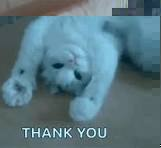

### Thanks for visiting my notebook 

</div>